#  Titanic Survival Prediction Using Machine Learning 

# Importing Libraries 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/titanic.csv")

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split


def split_dataframe(df, test_size=0.3, random_state=42):
    """
    Splits a pandas DataFrame into training and testing sets manually.

    Args:
        df (pd.DataFrame): The input DataFrame.
        test_size (float, optional): The proportion of the dataset to include in the test split. Defaults to 0.3.
        random_state (int, optional): Seed for reproducibility. Defaults to 42.

    Returns:
        tuple: A tuple containing (train_df, test_df).
    """
    np.random.seed(random_state)
    shuffled_indices = np.random.permutation(df.index)
    test_set_size = int(len(df) * test_size)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    
    return df.loc[train_indices], df.loc[test_indices]

In [4]:
train_data,test = split_dataframe(df, test_size=0.3, random_state=42)

# Loading Data

# EDA

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 624 entries, 430 to 102
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  624 non-null    int64  
 1   Survived     624 non-null    int64  
 2   Pclass       624 non-null    int64  
 3   Name         624 non-null    object 
 4   Sex          624 non-null    object 
 5   Age          500 non-null    float64
 6   SibSp        624 non-null    int64  
 7   Parch        624 non-null    int64  
 8   Ticket       624 non-null    object 
 9   Fare         624 non-null    float64
 10  Cabin        140 non-null    object 
 11  Embarked     623 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 63.4+ KB


In [9]:
df_num = train_data[["Age", "SibSp", "Parch", "Fare"]]
df_cat = train_data[["Survived", "Sex", "Cabin", "Embarked", "Ticket"]]

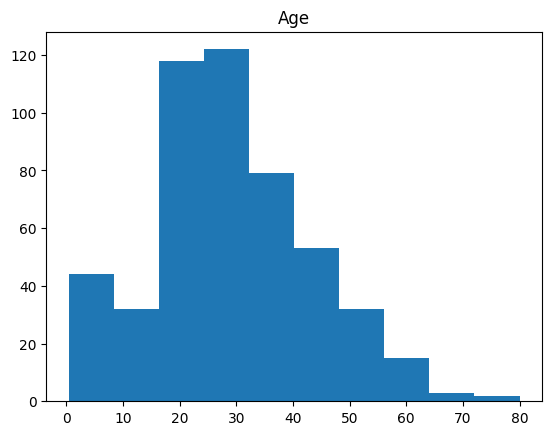

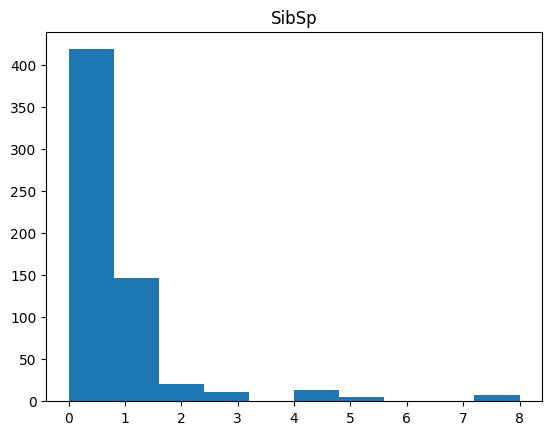

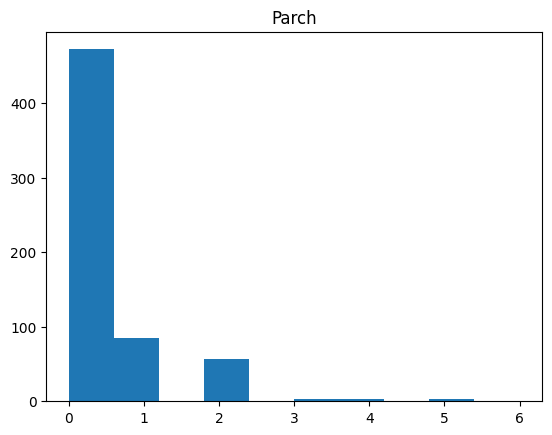

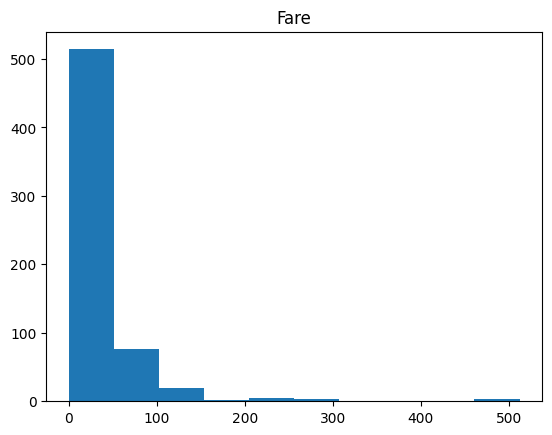

In [10]:
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

In [ ]:
pd.pivot_table(train_data, index="Survived", values=["Age", "SibSp", "Parch", "Fare"])

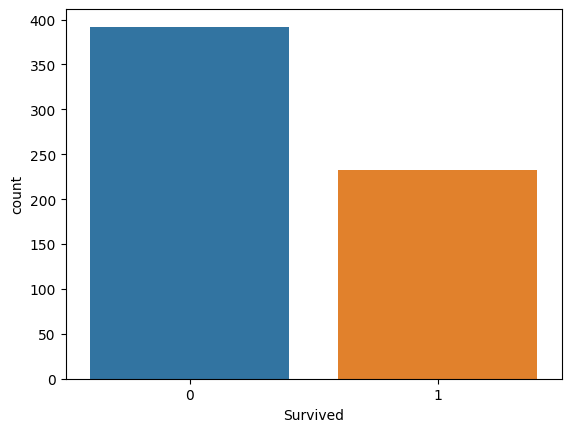

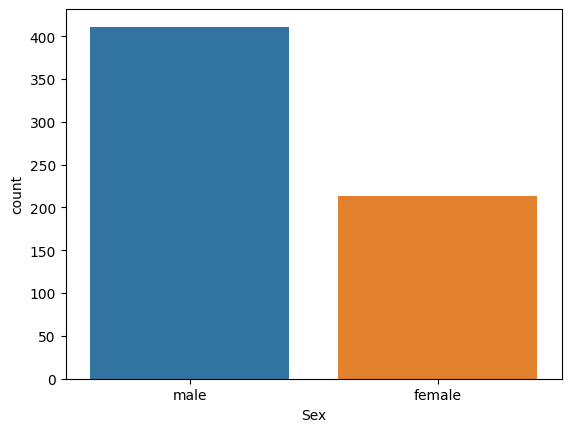

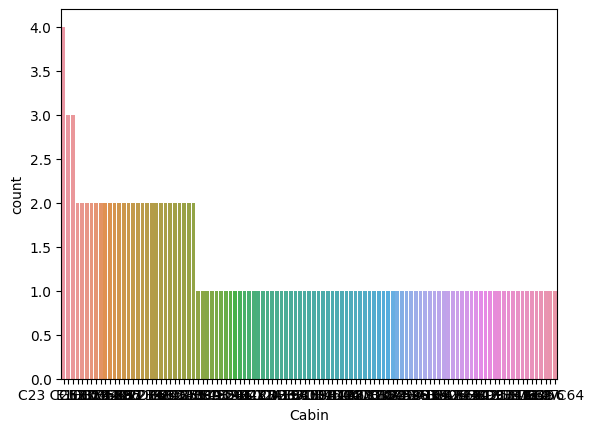

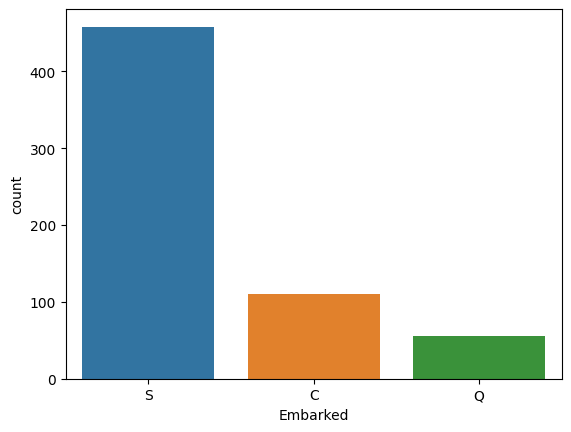

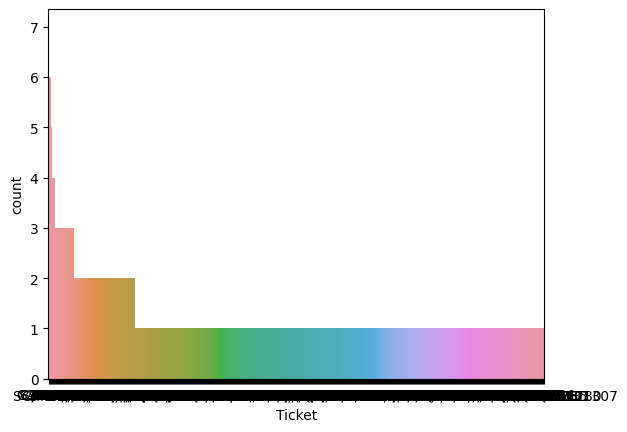

In [10]:
for i in df_cat.columns:
    sns.barplot(x=df_cat[i].value_counts().index, y=df_cat[i].value_counts())
    plt.show()

In [11]:
x = pd.DataFrame(
    (
        pd.pivot_table(
            train_data,
            index="Survived",
            columns="Sex",
            values="Ticket",
            aggfunc="count",
        )
    )
)
print()
print(
    pd.pivot_table(
        train_data, index="Survived", columns="Pclass", values="Ticket", aggfunc="count"
    )
)
print()
print(
    pd.pivot_table(
        train_data,
        index="Survived",
        columns="Embarked",
        values="Ticket",
        aggfunc="count",
    )
)
print()
x


Pclass     1   2    3
Survived             
0         56  69  267
1         84  63   85

Embarked   C   Q    S
Survived             
0         48  34  310
1         62  21  148



Sex,female,male
Survived,,
0,58,334
1,155,77


# Data Cleaning  

In [11]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            124
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          484
Embarked         1
dtype: int64

In [12]:
train_data = train_data.drop(columns=["PassengerId", "Cabin", "Name", "Ticket"])

In [13]:
train_data["Age"] = train_data["Age"].fillna(train_data["Age"].mean())

In [14]:
train_data["Embarked"] = train_data["Embarked"].fillna(train_data["Embarked"].mode()[0])

In [15]:
train_data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# Feature Enginneering 

In [16]:
train_data["Fare"] = np.log(train_data["Fare"] + 1)

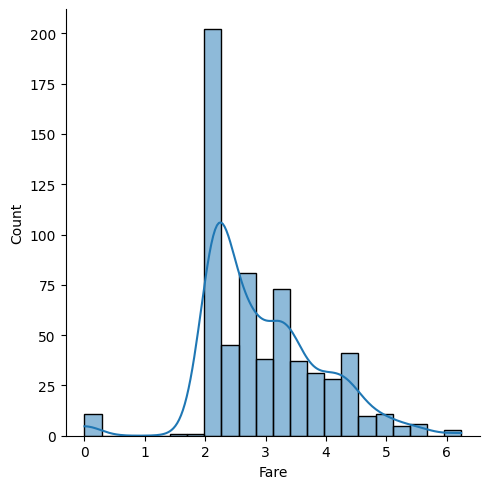

In [17]:
sns.displot(train_data["Fare"], kde=True)

<Axes: >

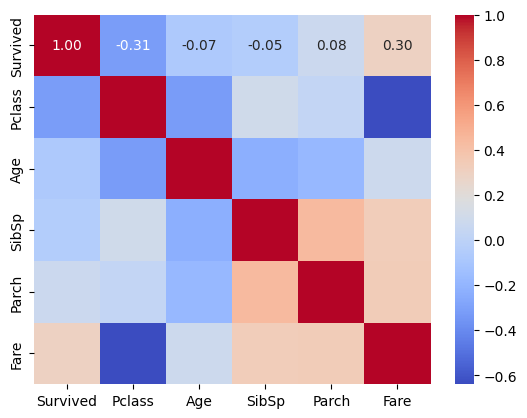

In [18]:
corr = train_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

In [19]:
from sklearn.preprocessing import LabelEncoder

cols = ["Sex", "Embarked"]
le = LabelEncoder()
for col in cols:
    train_data[col] = le.fit_transform(train_data[col])

train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
430,1,1,1,28.00000,0,0,3.316003,2
445,1,1,1,4.00000,0,2,4.417132,2
650,0,3,1,29.25384,0,0,2.185579,2
172,1,3,0,1.00000,1,1,2.495954,2
450,0,2,1,36.00000,1,2,3.358638,2


In [20]:
X = train_data.drop(columns=["Survived"], axis=1)
y = train_data["Survived"]
train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
430,1,1,1,28.00000,0,0,3.316003,2
445,1,1,1,4.00000,0,2,4.417132,2
650,0,3,1,29.25384,0,0,2.185579,2
172,1,3,0,1.00000,1,1,2.495954,2
450,0,2,1,36.00000,1,2,3.358638,2
...,...,...,...,...,...,...,...,...
106,1,3,0,21.00000,0,0,2.157559,2
270,0,1,1,29.25384,0,0,3.465736,2
860,0,3,1,41.00000,2,0,2.715244,2
435,1,1,0,14.00000,1,2,4.795791,2


# Setting up the Parameters for the Model  

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score


def classify(model):
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=40
    )
    model.fit(x_train, y_train)
    print("Accuracy", model.score(x_test, y_test))

    score = cross_val_score(model, X, y, cv=5)
    print("CV SCORE :", np.mean(score))

In [22]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
classify(model)

Accuracy 0.7692307692307693
CV SCORE : 0.7500129032258064


In [23]:
!pip install xgboost


[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from xgboost import XGBClassifier

model = XGBClassifier()
classify(model)

Accuracy 0.8141025641025641
CV SCORE : 0.7917290322580646


In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
classify(model)

Accuracy 0.8205128205128205
CV SCORE : 0.793341935483871


In [30]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier()
classify(model)

Accuracy 0.8012820512820513
CV SCORE : 0.7724903225806452


In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
classify(model)

Accuracy 0.7692307692307693
CV SCORE : 0.7965032258064516


In [27]:
model = XGBClassifier()
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [28]:
import xgboost as xgb
import pickle

def save_xgboost_model(model, filename):
    """
    Saves an XGBoost classifier model to a pickle file.

    Args:
        model (xgb.XGBClassifier): The trained XGBoost classifier model.
        filename (str): The name of the pickle file to save the model to (e.g., 'xgboost_model.pkl').
    """
    try:
        with open(filename, 'wb') as f:
            pickle.dump(model, f)
        print(f"XGBoost model saved to {filename}")
    except Exception as e:
        print(f"Error saving XGBoost model: {e}")

def load_xgboost_model(filename):
    """
    Loads an XGBoost classifier model from a pickle file.

    Args:
        filename (str): The name of the pickle file to load the model from.

    Returns:
        xgb.XGBClassifier: The loaded XGBoost classifier model, or None if an error occurred.
    """
    try:
        with open(filename, 'rb') as f:
            model = pickle.load(f)
        print(f"XGBoost model loaded from {filename}")
        return model
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return None
    except Exception as e:
        print(f"Error loading XGBoost model: {e}")
        return None

# Example Usage (assuming you have a trained XGBoost classifier named 'xgb_classifier'):

# 1. Train your xgboost model
# xgb_classifier = xgb.XGBClassifier()
# xgb_classifier.fit(X_train, y_train) #Train your model with training data.

# 2. Save the model:
# save_xgboost_model(xgb_classifier, 'xgboost_model.pkl')

# 3. Load the model:
# loaded_model = load_xgboost_model('xgboost_model.pkl')

# 4. Use the loaded model for predictions:
# if loaded_model:
#     predictions = loaded_model.predict(X_test) #use your test data.
#     # ... evaluate predictions ...

In [29]:
save_xgboost_model(model, '../Model Store/xgboost')

XGBoost model saved to ../Model Store/xgboost


In [30]:
model = load_xgboost_model('../Model Store/xgboost')

XGBoost model loaded from ../Model Store/xgboost


In [31]:
X_test = test.drop(columns=["PassengerId", "Name", "Cabin", "Ticket"], axis=1)

X_test

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,1,3,male,NaN,1,1,15.2458,C
439,0,2,male,31.0,0,0,10.5000,S
840,0,3,male,20.0,0,0,7.9250,S
720,1,2,female,6.0,0,1,33.0000,S
39,1,3,female,14.0,1,0,11.2417,C
...,...,...,...,...,...,...,...,...
346,1,2,female,40.0,0,0,13.0000,S
821,1,3,male,27.0,0,0,8.6625,S
633,0,1,male,NaN,0,0,0.0000,S
456,0,1,male,65.0,0,0,26.5500,S


In [32]:
from sklearn.preprocessing import LabelEncoder

cols = ["Sex", "Embarked"]
le = LabelEncoder()

for col in cols:
    X_test[col] = le.fit_transform(X_test[col])

X_test.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,1,3,1,NaN,1,1,15.2458,0
439,0,2,1,31.0,0,0,10.5000,2
840,0,3,1,20.0,0,0,7.9250,2
720,1,2,0,6.0,0,1,33.0000,2
39,1,3,0,14.0,1,0,11.2417,0


In [33]:
X_test["Age"] = X_test["Age"].fillna(X_test["Age"].mean())
X_test["Fare"] = X_test["Fare"].fillna(X_test["Fare"].mean())

X_test.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# Data Preprocessing

In [34]:
X_test = test.drop(columns=["PassengerId", "Name", "Cabin", "Ticket","Survived"], axis=1)

X_test["Age"] = X_test["Age"].fillna(X_test["Age"].mean())
X_test["Fare"] = X_test["Fare"].fillna(X_test["Fare"].mean())

X_test.isnull().sum()

from sklearn.preprocessing import LabelEncoder

cols = ["Sex", "Embarked"]
le = LabelEncoder()

for col in cols:
    X_test[col] = le.fit_transform(X_test[col])

X_test.head()
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,3,1,30.739486,1,1,15.2458,0
439,2,1,31.000000,0,0,10.5000,2
840,3,1,20.000000,0,0,7.9250,2
720,2,0,6.000000,0,1,33.0000,2
39,3,0,14.000000,1,0,11.2417,0
...,...,...,...,...,...,...,...
346,2,0,40.000000,0,0,13.0000,2
821,3,1,27.000000,0,0,8.6625,2
633,1,1,30.739486,0,0,0.0000,2
456,1,1,65.000000,0,0,26.5500,2


# Model Testing 

In [35]:
pred = model.predict(X_test)
pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0])

# Test Submission 

In [ ]:
submit = pd.read_csv("data/gender_submission.csv")
submit

In [ ]:
submit["Survived"] = pred

submit

In [ ]:
submit.info()

In [ ]:
submit.to_csv("Submission.csv", index=False)

# The Accuracy of the Model is 73.8%